
# HR Analytics: Employee Salary Prediction Model

## 1. Introduction

This notebook presents a comprehensive HR analytics solution focused on developing a predictive model for employee annual salaries. In today's competitive talent landscape, understanding the factors that influence compensation is crucial for fair pay practices, talent retention, and strategic workforce planning. This model aims to provide data-driven insights into salary structures, enabling organizations to make informed decisions regarding compensation and identify key drivers of employee earnings.

The project encompasses the following key stages:

1.  **Data Generation:** Creation of a synthetic dataset simulating realistic HR employee data, including experience level, education, performance ratings, training hours, and annual salary.
2.  **Exploratory Data Analysis (EDA):** In-depth analysis of the dataset to understand distributions, relationships between variables, and identify potential trends or anomalies influencing salary.
3.  **Data Preprocessing:** Preparation of the data for machine learning, involving handling categorical variables through ordinal encoding and scaling numerical features to optimize model performance.
4.  **Model Development:** Training a Linear Regression model to predict annual salaries based on the identified predictors.
5.  **Model Evaluation:** Assessment of the model's performance using key metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), R-squared (R2), and Mean Absolute Percentage Error (MAPE).
6.  **Prediction Function:** Development of a user-friendly function to predict salaries for new or hypothetical employee profiles.

The insights gained from this analysis and the predictive model can support HR professionals and business leaders in:
*   Ensuring equitable compensation across different employee segments.
*   Forecasting salary costs for budgeting and planning.
*   Identifying the most impactful factors on employee earnings.
*   Supporting talent acquisition by providing competitive salary estimates.

This documentation aims to clearly articulate each step of the process, making the methodology and results transparent and actionable.


In [32]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Define realistic categorical mappings
experience_levels = ["Entry-Level", "Mid-Level", "Senior", "Executive"]
education_levels = ["Bachelor's Degree", "Master's Degree", "Doctoral Degree"]
performance_ratings = ["Needs Improvement", "Meets Expectations", "Exceeds Expectations", "Outstanding"]

# Generate 1000 realistic employee records
data = []
for i in range(1, 1001):
    emp_id = f"EMP{1000+i}"

    # Weighted random choices for realistic organizational distribution
    exp_level = np.random.choice(experience_levels, p=[0.3, 0.4, 0.2, 0.1])
    edu_level = np.random.choice(education_levels, p=[0.5, 0.4, 0.1])
    perf_rating = np.random.choice(performance_ratings, p=[0.1, 0.4, 0.35, 0.15])

    # Realistic training hours based on experience level
    if exp_level == "Entry-Level":
        training_hours = np.random.randint(10, 30)
    elif exp_level == "Mid-Level":
        training_hours = np.random.randint(20, 45)
    elif exp_level == "Senior":
        training_hours = np.random.randint(30, 55)
    else:
        training_hours = np.random.randint(40, 60)

    # Base salary calculation with logical increments
    base_salary = 60000
    if exp_level == "Mid-Level": base_salary += 15000
    elif exp_level == "Senior": base_salary += 35000
    elif exp_level == "Executive": base_salary += 55000

    if edu_level == "Master's Degree": base_salary += 8000
    elif edu_level == "Doctoral Degree": base_salary += 15000

    if perf_rating == "Meets Expectations": base_salary += 2000
    elif perf_rating == "Exceeds Expectations": base_salary += 7000
    elif perf_rating == "Outstanding": base_salary += 12000

    # Add training bonus ($50 per hour) and realistic random noise
    salary = base_salary + (training_hours * 50) + np.random.randint(-3000, 3000)

    data.append({
        "Employee_ID": emp_id,
        "Experience_Level": exp_level,
        "Education_Level": edu_level,
        "Performance_Rating": perf_rating,
        "Training_Hours": training_hours,
        "Annual_Salary_USD": salary
    })

df_dataset = pd.DataFrame(data)

df_dataset.head()


,Employee_ID,Experience_Level,Education_Level,Performance_Rating,Training_Hours,Annual_Salary_USD
0,EMP1001,Mid-Level,Doctoral Degree,Exceeds Expectations,40,101734
1,EMP1002,Mid-Level,Bachelor's Degree,Meets Expectations,40,79171
2,EMP1003,Entry-Level,Master's Degree,Needs Improvement,21,68483
3,EMP1004,Entry-Level,Bachelor's Degree,Meets Expectations,21,62954
4,EMP1005,Entry-Level,Master's Degree,Meets Expectations,25,70056


In [33]:
# Define the logical order for ordinal variables to ensure correct plotting
exp_order = ['Entry-Level', 'Mid-Level', 'Senior', 'Executive']
edu_order = ["Bachelor's Degree", "Master's Degree", "Doctoral Degree"]
perf_order = ['Needs Improvement', 'Meets Expectations', 'Exceeds Expectations', 'Outstanding']


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
print(df_dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Employee_ID         1000 non-null   object
 1   Experience_Level    1000 non-null   object
 2   Education_Level     1000 non-null   object
 3   Performance_Rating  1000 non-null   object
 4   Training_Hours      1000 non-null   int64 
 5   Annual_Salary_USD   1000 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 47.0+ KB
None


In [36]:
print(df_dataset.describe(include='all'))

       Employee_ID Experience_Level    Education_Level  Performance_Rating  \
count         1000             1000               1000                1000   
unique        1000                4                  3                   4   
top        EMP2000        Mid-Level  Bachelor's Degree  Meets Expectations   
freq             1              403                503                 397   
mean           NaN              NaN                NaN                 NaN   
std            NaN              NaN                NaN                 NaN   
min            NaN              NaN                NaN                 NaN   
25%            NaN              NaN                NaN                 NaN   
50%            NaN              NaN                NaN                 NaN   
75%            NaN              NaN                NaN                 NaN   
max            NaN              NaN                NaN                 NaN   

        Training_Hours  Annual_Salary_USD  
count      1000.000

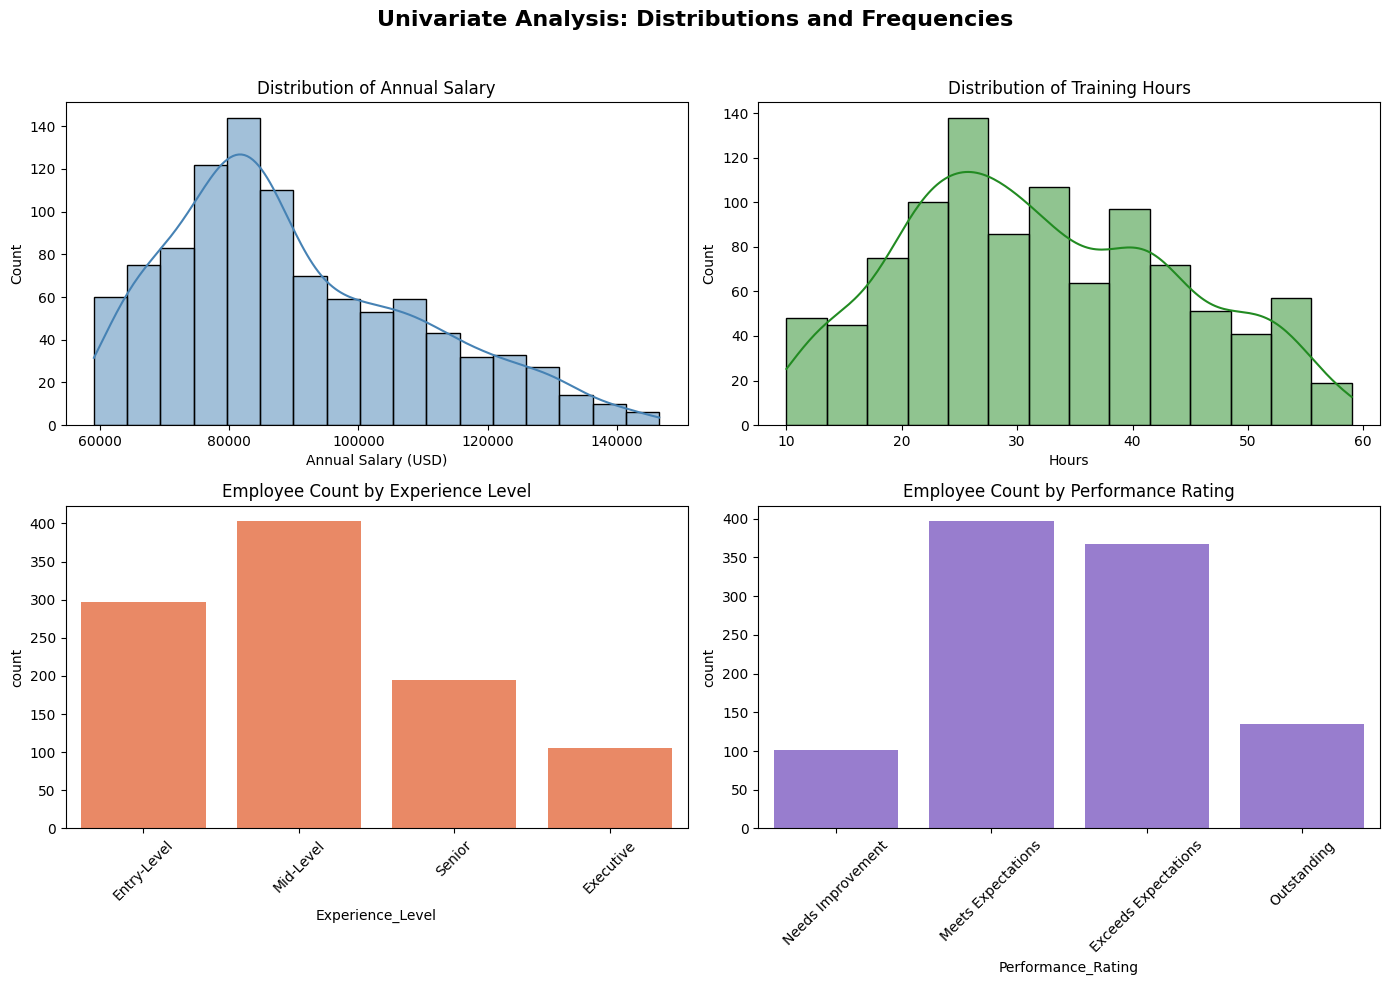

In [37]:
# ==============================================================================
# Univariate Analysis (Distributions and Frequencies)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Univariate Analysis: Distributions and Frequencies', fontsize=16, fontweight='bold')

# Target Variable Distribution
sns.histplot(df_dataset['Annual_Salary_USD'], kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution of Annual Salary')
axes[0, 0].set_xlabel('Annual Salary (USD)')

# Continuous Predictor Distribution
sns.histplot(df_dataset['Training_Hours'], kde=True, ax=axes[0, 1], color='forestgreen')
axes[0, 1].set_title('Distribution of Training Hours')
axes[0, 1].set_xlabel('Hours')

# Categorical Predictor Frequencies
sns.countplot(x='Experience_Level', data=df_dataset, ax=axes[1, 0], order=exp_order, color='coral')
axes[1, 0].set_title('Employee Count by Experience Level')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.countplot(x='Performance_Rating', data=df_dataset, ax=axes[1, 1], order=perf_order, color='mediumpurple')
axes[1, 1].set_title('Employee Count by Performance Rating')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

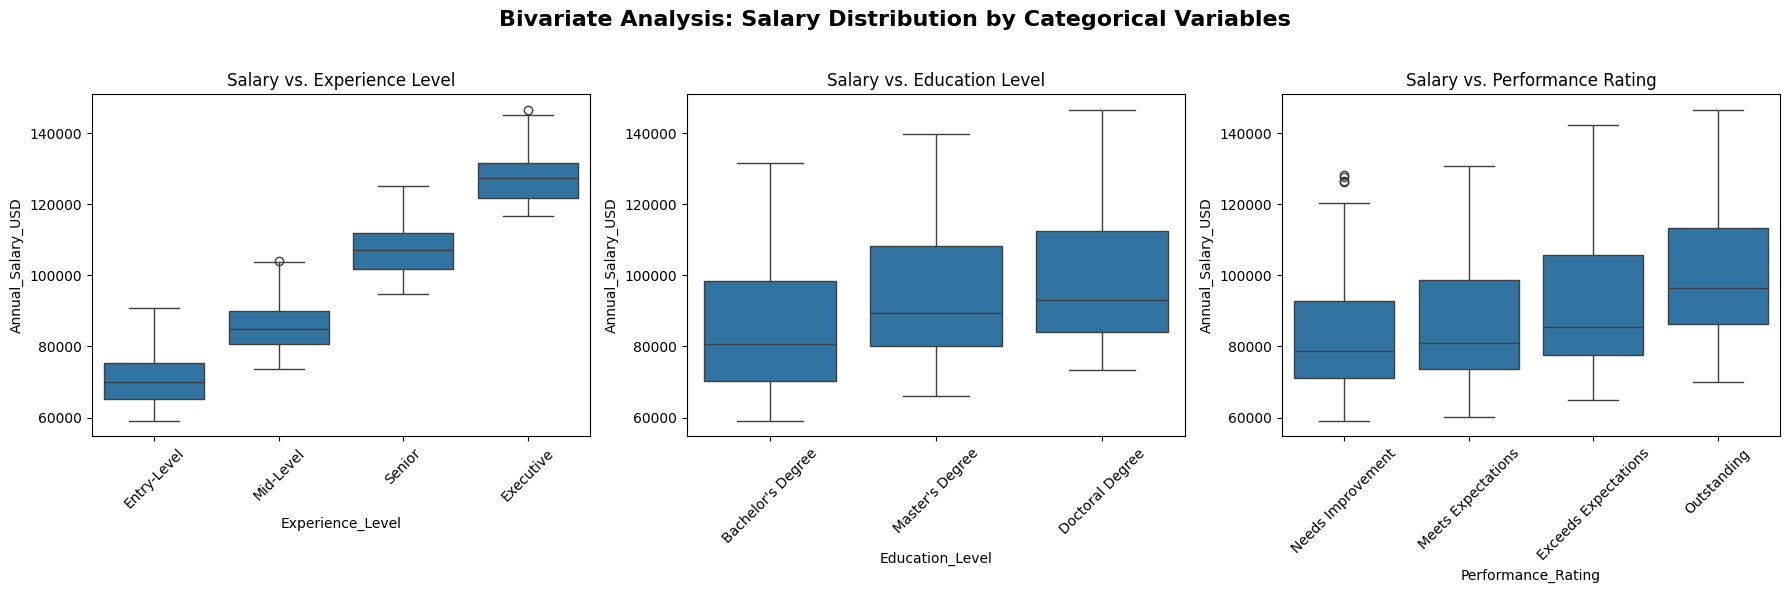

In [38]:
# ==============================================================================
# Bivariate Analysis: Categorical vs. Continuous
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Bivariate Analysis: Salary Distribution by Categorical Variables', fontsize=16, fontweight='bold')

# Using boxplots to show median, quartiles, and outliers
sns.boxplot(x='Experience_Level', y='Annual_Salary_USD', data=df_dataset, ax=axes[0], order=exp_order)
axes[0].set_title('Salary vs. Experience Level')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='Education_Level', y='Annual_Salary_USD', data=df_dataset, ax=axes[1], order=edu_order)
axes[1].set_title('Salary vs. Education Level')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(x='Performance_Rating', y='Annual_Salary_USD', data=df_dataset, ax=axes[2], order=perf_order)
axes[2].set_title('Salary vs. Performance Rating')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


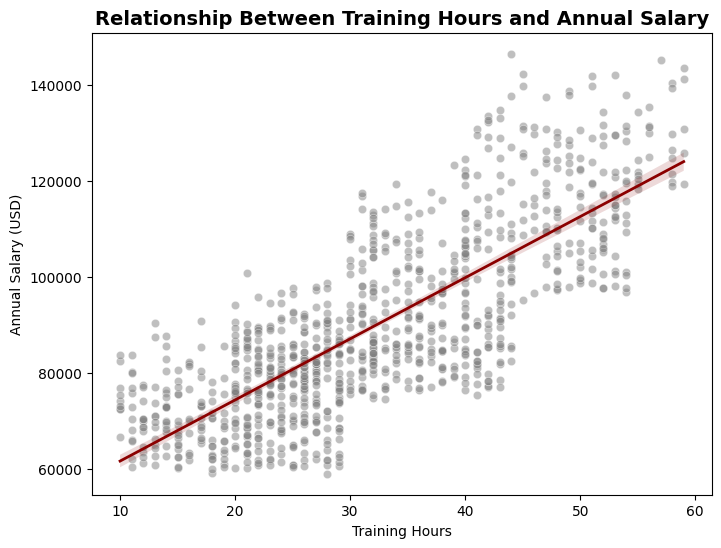

In [39]:
# ==============================================================================
# Bivariate Analysis: Continuous vs. Continuous
# ==============================================================================
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Training_Hours', y='Annual_Salary_USD', data=df_dataset, alpha=0.5, color='gray')
# Overlay a linear regression trendline
sns.regplot(x='Training_Hours', y='Annual_Salary_USD', data=df_dataset, scatter=False, color='darkred', line_kws={"linewidth": 2})
plt.title('Relationship Between Training Hours and Annual Salary', fontsize=14, fontweight='bold')
plt.xlabel('Training Hours')
plt.ylabel('Annual Salary (USD)')
plt.show()

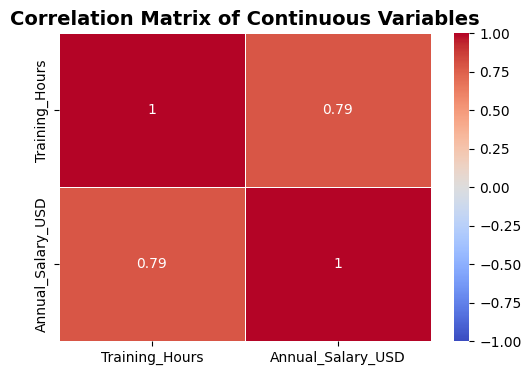

In [40]:
# ==============================================================================
# Correlation Matrix
# ==============================================================================
plt.figure(figsize=(6, 4))
numeric_cols = ['Training_Hours', 'Annual_Salary_USD']
correlation_matrix = df_dataset[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Continuous Variables', fontsize=14, fontweight='bold')
plt.show()

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Drop the unique identifier as it possesses no predictive value for regression
df = df_dataset.drop(columns=['Employee_ID'])

# Check for missing values (A standard practice, though our synthetic data is complete)
print("Missing values per column:\n", df_dataset.isnull().sum(), "\n")

# ==============================================================================
# Feature and Target Separation
# ==============================================================================
X = df_dataset.drop(columns=['Annual_Salary_USD'])
y = df_dataset['Annual_Salary_USD']

# ==============================================================================
# Train-Test Split
# ==============================================================================
# Pedagogical Note: We split the data BEFORE preprocessing to prevent data leakage.
# The scaler and encoder must only learn parameters (mean, variance, categories)
# from the training set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==============================================================================
# 4. Define Preprocessing Transformations
# ==============================================================================
# Identify categorical and numerical columns
categorical_cols = ['Experience_Level', 'Education_Level', 'Performance_Rating']
numerical_cols = ['Training_Hours']

# Define the explicit ordinal mappings to preserve the hierarchical nature of the data
ordinal_mappings = [
    ['Entry-Level', 'Mid-Level', 'Senior', 'Executive'],
    ["Bachelor's Degree", "Master's Degree", "Doctoral Degree"],
    ['Needs Improvement', 'Meets Expectations', 'Exceeds Expectations', 'Outstanding']
]

# Initialize the transformers
ordinal_encoder = OrdinalEncoder(categories=ordinal_mappings)
scaler = StandardScaler()

# Combine transformers using ColumnTransformer for a clean, modular pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', ordinal_encoder, categorical_cols),
        ('num', scaler, numerical_cols)
    ])

# ==============================================================================
# 5. Apply Preprocessing
# ==============================================================================
# Fit on training data and transform both training and testing sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# ==============================================================================
# 6. Reconstruct DataFrame for Interpretability
# ==============================================================================
# Extract the updated feature names generated by the ColumnTransformer
feature_names = preprocessor.get_feature_names_out()

# Convert the numpy arrays back into pandas DataFrames for easy inspection and modeling
X_train_final = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_final = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)



Missing values per column:
 Employee_ID           0
Experience_Level      0
Education_Level       0
Performance_Rating    0
Training_Hours        0
Annual_Salary_USD     0
dtype: int64 



In [42]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the preprocessed training data
linear_model.fit(X_train_final, y_train)

# Make predictions on the preprocessed test data
y_pred = linear_model.predict(X_test_final)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.4f}")

# Display model coefficients and intercept
print("\nModel Coefficients:")
coefficients_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Coefficient': linear_model.coef_
})
print(coefficients_df)
print(f"\nModel Intercept: {linear_model.intercept_:.2f}")

Model Performance on Test Set:
Mean Absolute Error (MAE): 1940.06
Mean Squared Error (MSE): 5667823.65
Root Mean Squared Error (RMSE): 2380.72
R-squared (R2): 0.9800

Model Coefficients:
                   Feature   Coefficient
0    cat__Experience_Level  18426.484867
1     cat__Education_Level   7883.494707
2  cat__Performance_Rating   4517.557856
3      num__Training_Hours    367.698337

Model Intercept: 57814.87


In [43]:
def mean_absolute_percentage_error(y_true, y_pred):
    # Avoid division by zero by replacing 0s in y_true with a small epsilon
    epsilon = np.finfo(np.float64).eps
    y_true_safe = np.where(y_true == 0, epsilon, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100

# Calculate MAPE for the training set
y_train_pred = linear_model.predict(X_train_final)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
print(f"Mean Absolute Percentage Error (MAPE) on Training Set: {mape_train:.2f}%")

# Calculate MAPE for the test set
# y_pred was already calculated in the previous cell
mape_test = mean_absolute_percentage_error(y_test, y_pred)
print(f"Mean Absolute Percentage Error (MAPE) on Test Set: {mape_test:.2f}%")

Mean Absolute Percentage Error (MAPE) on Training Set: 2.32%
Mean Absolute Percentage Error (MAPE) on Test Set: 2.31%


In [44]:
def predict_salary(experience_level, education_level, performance_rating, training_hours):
    """
    Predicts the annual salary based on given employee attributes.

    Args:
        experience_level (str): The experience level of the employee.
        education_level (str): The education level of the employee.
        performance_rating (str): The performance rating of the employee.
        training_hours (int): The number of training hours completed by the employee.

    Returns:
        float: The predicted annual salary in USD.
    """
    # Create a DataFrame from the input, matching the structure of X_train
    input_data = pd.DataFrame([{
        'Experience_Level': experience_level,
        'Education_Level': education_level,
        'Performance_Rating': performance_rating,
        'Training_Hours': training_hours
    }])

    # Preprocess the input data using the pre-fitted preprocessor
    input_processed = preprocessor.transform(input_data)

    # Convert processed input to DataFrame with correct column names for the model
    input_processed_df = pd.DataFrame(input_processed, columns=preprocessor.get_feature_names_out())

    # Predict salary using the trained linear model
    predicted_salary = linear_model.predict(input_processed_df)[0]

    return predicted_salary

In [45]:
predicted_salary_example = predict_salary(
    experience_level='Senior',
    education_level='Master\'s Degree',
    performance_rating='Exceeds Expectations',
    training_hours=50
)
print(f"Predicted Salary: ${predicted_salary_example:.2f}")

Predicted Salary: $112130.43


In [46]:
predicted_salary_example_2 = predict_salary(
    experience_level='Entry-Level',
    education_level='Bachelor\'s Degree',
    performance_rating='Meets Expectations',
    training_hours=20
)
print(f"Predicted Salary: ${predicted_salary_example_2:.2f}")

Predicted Salary: $61951.93
